In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [2]:
# Load training and testing datasets

train = pd.read_csv(r"C:\Users\HP\Documents\Sravya\excelr\Assignments\Logistic Regression\Titanic_train.csv")
test = pd.read_csv(r"C:\Users\HP\Documents\Sravya\excelr\Assignments\Logistic Regression\Titanic_test.csv")

# Display first 5 rows
print(train.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [3]:
#EXPLORATORY ANALYSIS
# Display dataset information

print(train.info())

# Display summary statistics
print(train.describe())

# Display missing values
print(train.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.48659

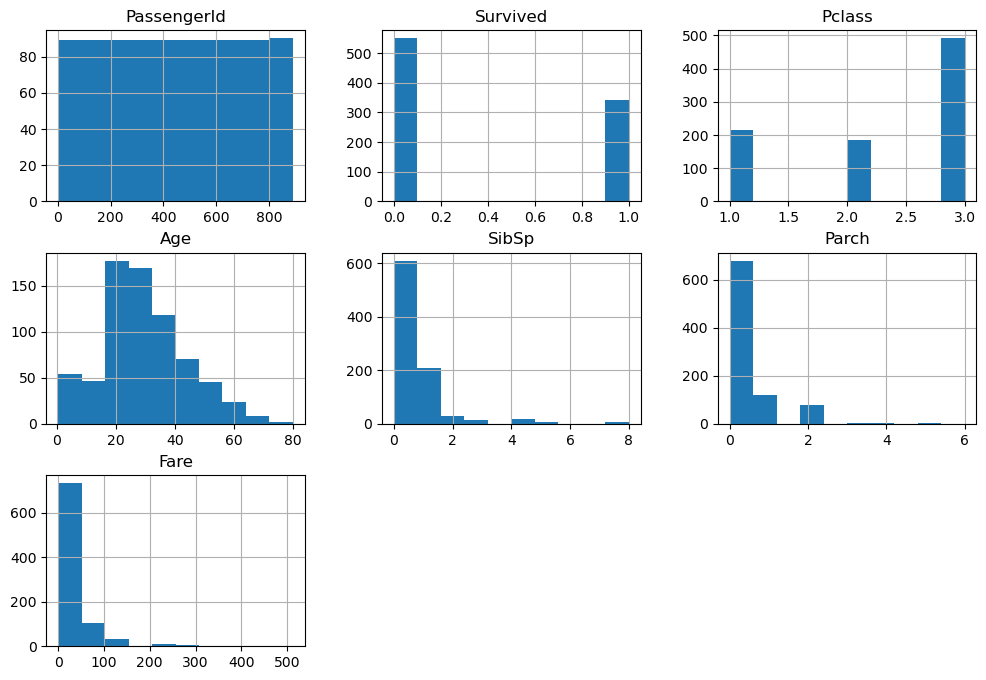

In [5]:
# Plot histogram of numerical columns

train.hist(figsize=(12,8))
plt.show()


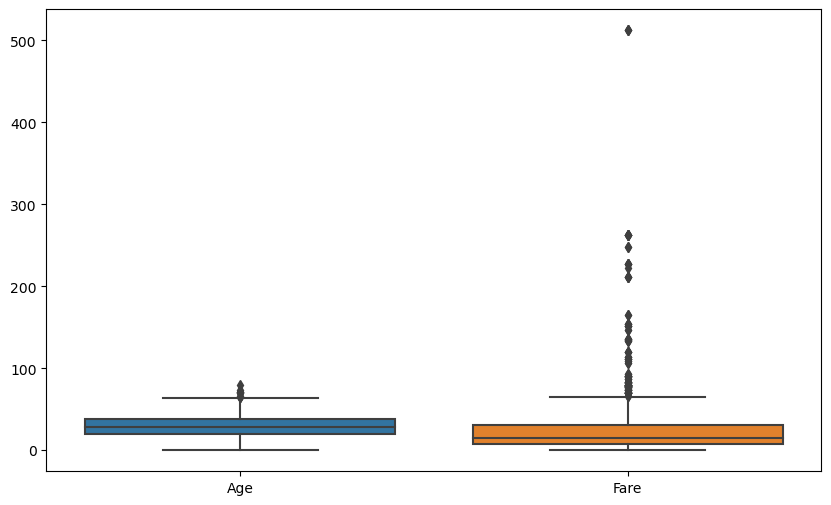

In [8]:
# Boxplots help detect outliers

plt.figure(figsize=(10,6))
sns.boxplot(data=train[['Age','Fare']])
plt.show()

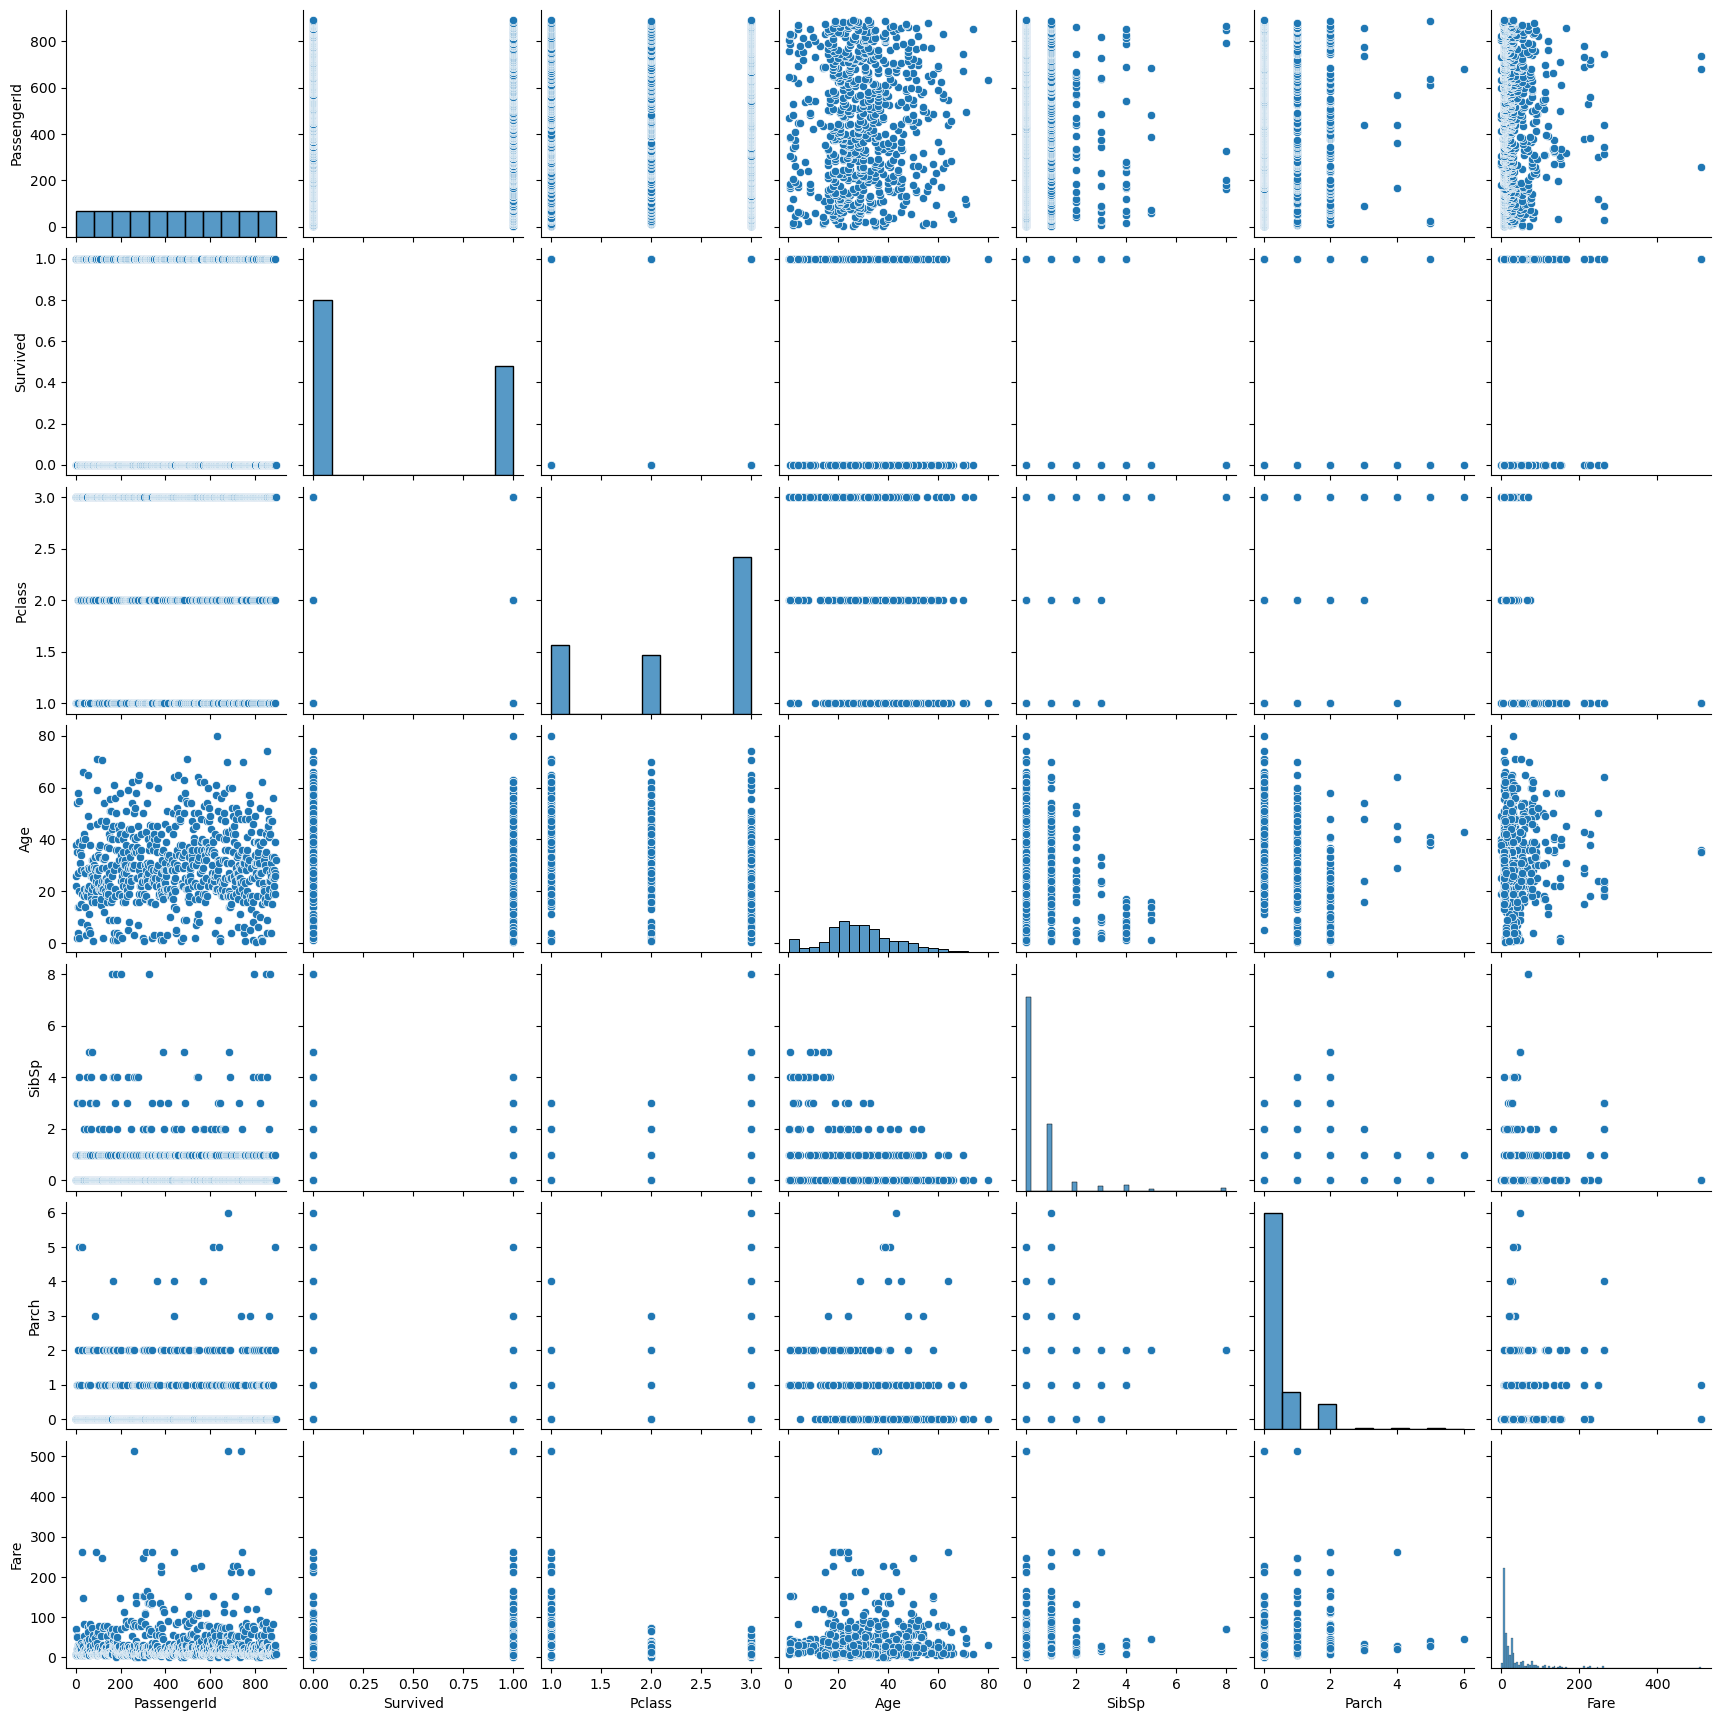

In [11]:
import warnings
warnings.filterwarnings(
    "ignore", category=UserWarning, module="seaborn.axisgrid"
)


sns.pairplot(train)
plt.show()

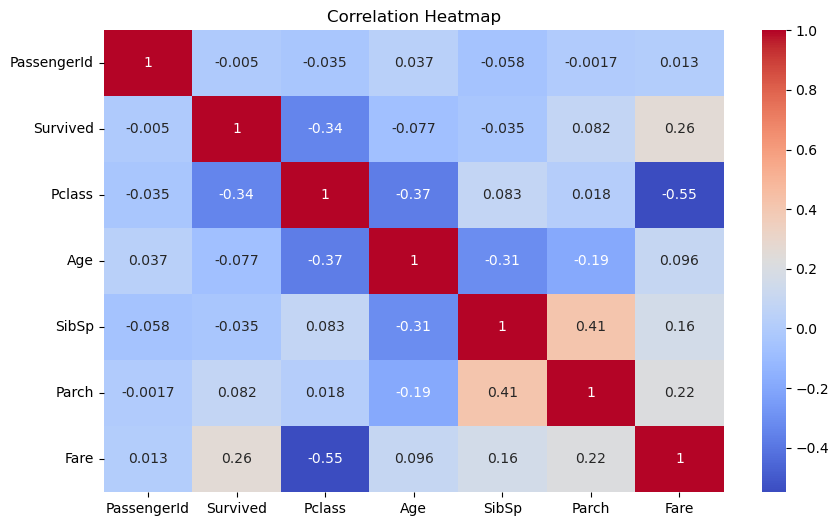

In [55]:
# Select only numerical columns
numeric_train = train.select_dtypes(include=np.number)

# Correlation matrix
plt.figure(figsize=(10,6))
sns.heatmap(numeric_train.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [56]:
#Data Preprocessing
#Handle Missing Values
# Fill missing Age with median

train['Age'].fillna(train['Age'].median(), inplace=True)
test['Age'].fillna(test['Age'].median(), inplace=True)

# Fill missing Fare
test['Fare'].fillna(test['Fare'].median(), inplace=True)

# Fill missing Embarked with mode
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)

# Drop Cabin because it contains too many missing values
train.drop(columns=['Cabin'], inplace=True)
test.drop(columns=['Cabin'], inplace=True)

In [84]:
#Encode Categorical Variables
# Create Label Encoder
le = LabelEncoder()

# Convert Sex into numerical values
train['Sex'] = le.fit_transform(train['Sex'])
test['Sex'] = le.transform(test['Sex'])

# Convert Embarked into numerical values
train['Embarked'] = le.fit_transform(train['Embarked'])
test['Embarked'] = le.transform(test['Embarked'])

print(train['Sex'])
print(train['Embarked'])

0      1
1      0
2      0
3      0
4      1
      ..
886    1
887    0
888    0
889    1
890    1
Name: Sex, Length: 891, dtype: int64
0      2
1      0
2      2
3      2
4      2
      ..
886    2
887    2
888    2
889    0
890    1
Name: Embarked, Length: 891, dtype: int64


In [58]:
#Drop Unnecessary Columns
# PassengerId, Name and Ticket do not help prediction

train.drop(columns=['PassengerId','Name','Ticket'], inplace=True)
test.drop(columns=['PassengerId','Name','Ticket'], inplace=True)

In [59]:
X = train.drop("Survived", axis=1)
y = train["Survived"]

In [60]:
# Split training data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [61]:
#Build Logistic Regression Model
# Create model

model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [62]:
#Prediction
# Predict class labels

y_pred = model.predict(X_test)

# Predict probabilities
y_prob = model.predict_proba(X_test)[:,1]

In [63]:
#Model Evaluation
#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

Accuracy : 0.8100558659217877


In [64]:
#Precision
precision = precision_score(y_test, y_pred)
print("Precision :", precision)

Precision : 0.7857142857142857


In [65]:
#Recall
recall = recall_score(y_test, y_pred)
print("Recall :", recall)

Recall : 0.7432432432432432


In [66]:
#F1 Score
f1 = f1_score(y_test, y_pred)
print("F1 Score :", f1)

F1 Score : 0.7638888888888888


In [67]:
#ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC :", roc_auc)

ROC-AUC : 0.8823680823680824


In [68]:
#Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



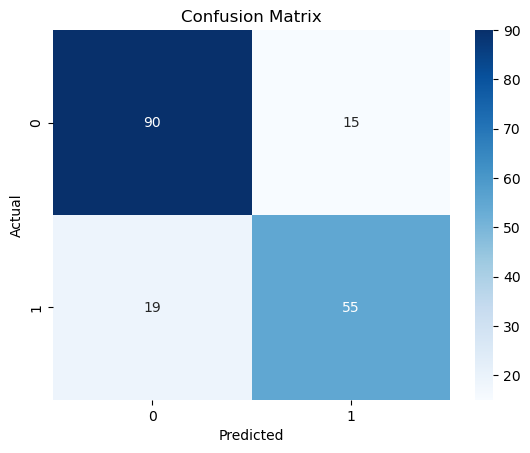

In [69]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

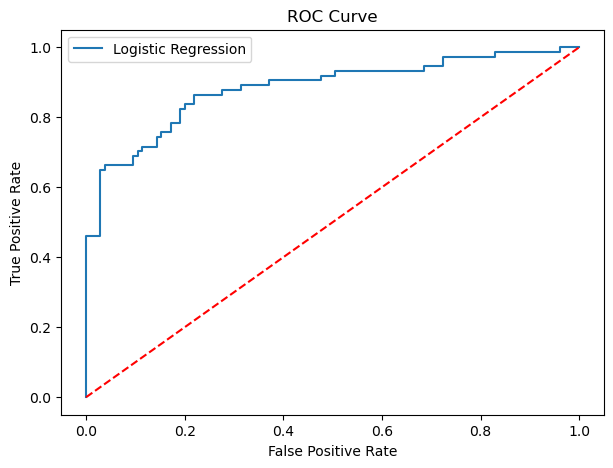

In [70]:
#ROC Curve
# Calculate ROC values

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Plot ROC curve

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label="Logistic Regression")

# Diagonal reference line
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [71]:
#Feature Importance (Coefficient Interpretation)
# Create dataframe of coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(coefficients.sort_values(by="Coefficient", ascending=False))

    Feature  Coefficient
5      Fare     0.002533
2       Age    -0.030430
4     Parch    -0.111821
6  Embarked    -0.218850
3     SibSp    -0.293865
0    Pclass    -0.930727
1       Sex    -2.596708


In [72]:
#Predict on the Given Test Dataset
# Predict survival on Titanic_test.csv

test_predictions = model.predict(test)

print(test_predictions)

[0 0 0 0 1 0 1 0 1 0 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 0 1 0 0 0 0 0 0 1 0 0 1
 1 0 0 0 0 0 1 1 0 0 0 1 1 0 0 1 1 0 0 0 0 0 1 0 0 0 1 1 1 1 0 1 1 1 0 1 1
 1 1 0 1 0 1 0 0 0 0 0 0 1 1 1 0 1 0 1 0 1 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0
 1 1 1 1 0 0 1 1 1 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0
 0 0 1 0 0 1 0 0 1 1 0 1 1 0 1 0 0 1 0 0 1 1 0 0 0 0 0 1 1 0 1 1 0 0 1 0 1
 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 0 1 0 1 1 0 1 0 0 0 0 1 0 0 1 0 1 0 1 0
 1 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 1 1 1 0 1 0 0 0 0 0 1
 0 0 0 1 1 0 0 0 0 1 0 0 0 1 1 0 1 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 1 0 0 0 0
 1 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0
 1 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 1 0 0 1 1 0
 0 1 0 0 1 1 1 0 0 0 0 0 1 1 0 1 0 0 0 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 0 0 0
 0 1 1 1 1 1 0 1 0 0 0]


In [73]:
#Save Predictions
# Save predictions to CSV

output = pd.DataFrame({
    "Prediction": test_predictions
})

output.to_csv("Titanic_Predictions.csv", index=False)

print("Prediction file saved successfully.")

Prediction file saved successfully.


In [77]:
# Save the Model (Useful for Streamlit)
import pickle

with open("logistic_model.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model saved successfully.")

Model saved successfully.


In [78]:
import pickle

with open("logistic_model.pkl", "rb") as f:
    obj = pickle.load(f)
print(type(obj))
print(obj)

<class 'sklearn.linear_model._logistic.LogisticRegression'>
LogisticRegression(max_iter=1000)


In [88]:
%%writefile app.py
import pickle
import streamlit as st
from PIL import Image


with open("logistic_model.pkl", "rb") as f:
    logistic_model = pickle.load(f)

def welcome():
    return "Welcome All"

# Import your model here (assuming it's loaded via pickle/joblib as `logistic_model`)

def prediction(Pclass, Sex, Age, SibSp, Parch, Fare, Embarked):
    # 1. Map 'Sex' to the exact numeric values used during training
    sex_encoded = 1 if Sex == "male" else 0
    
    # 2. Map 'Embarked' to numeric values 
    embarked_mapping = {'C': 0, 'Q': 1, 'S': 2}
    embarked_encoded = embarked_mapping.get(Embarked, 2) # Default to 'S' if not found
    
    # 3. Convert all variables explicitly to float numbers
    features = [
        float(Pclass),
        float(sex_encoded),
        float(Age),
        float(SibSp),
        float(Parch),
        float(Fare),
        float(embarked_encoded)
    ]
    
    # 4. Predict using a 2D array structure
    survival_prediction = logistic_model.predict([features])
    return survival_prediction[0]

def main():
    html_temp = """
    <div style="background-color:violet;padding:10px">
    <h2 style="color:white;text-align:center">Streamlit Titanic Survival Prediction App</h2>
    </div>
    """
    st.markdown(html_temp, unsafe_allow_html=True)
    
    # Use selectbox and numeric inputs instead of raw text boxes
    Pclass = st.selectbox("PClass", [1, 2, 3])
    Sex = st.selectbox("Sex", ["male", "female"])
    Age = st.number_input("Age", min_value=0, max_value=100)
    SibSp = st.number_input("SibSp", min_value=0, value=0)
    Parch = st.number_input("Parch", min_value=0, value=0)
    Fare = st.number_input("Fare", min_value=0.0,)
    Embarked = st.selectbox("Embarked", ["S", "C", "Q"])
    
    result = ""
    if st.button("Predict Survival"):
        result = prediction(Pclass, Sex, Age, SibSp, Parch, Fare, Embarked)
        
        # Make the output user-friendly
        if result == 1:
            st.success("The output is: Survived!")
        else:
            st.error("The output is: Did not survive.")

if __name__ == '__main__':
    main()

Overwriting app.py
